# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [1]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [2]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [3]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [4]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [6]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [7]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')

In [8]:
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

In [9]:
print("""
LabelEncoder: Asigna números enteros (0, 1, 2...) a cada categoría
- Problema: El modelo puede asumir un orden (1 > 0)
- Usa menos memoria
- Mejor para variables ordinales

OneHotEncoder: Crea columnas binarias (0, 1) por cada categoría
- Ventaja: Sin orden implícito, cada categoría es independiente
- Usa más memoria
- Mejor para variables nominales
- IDEAL para modelos de ML
""")


LabelEncoder: Asigna números enteros (0, 1, 2...) a cada categoría
- Problema: El modelo puede asumir un orden (1 > 0)
- Usa menos memoria
- Mejor para variables ordinales

OneHotEncoder: Crea columnas binarias (0, 1) por cada categoría
- Ventaja: Sin orden implícito, cada categoría es independiente
- Usa más memoria
- Mejor para variables nominales
- IDEAL para modelos de ML



### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

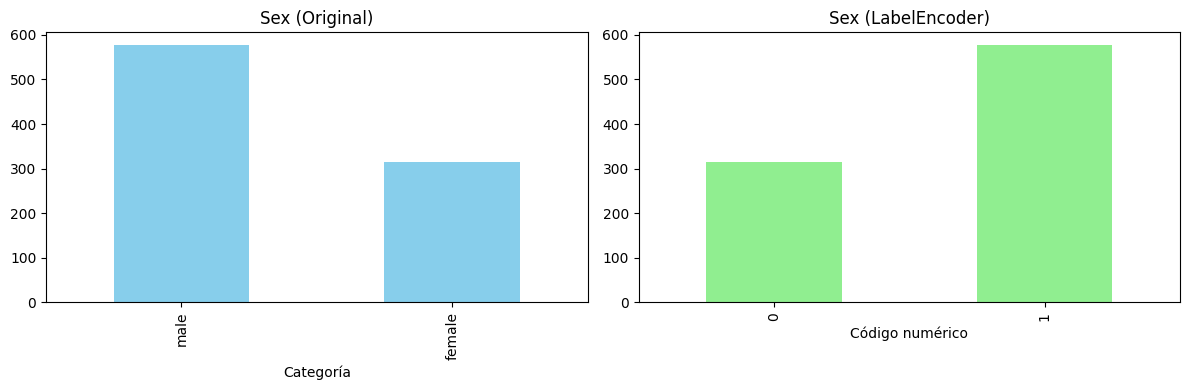

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))


data['sex'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Sex (Original)')
axes[0].set_xlabel('Categoría')


data['sex_label'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Sex (LabelEncoder)')
axes[1].set_xlabel('Código numérico')

plt.tight_layout()
plt.show()

### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

In [11]:
onehot_class = pd.get_dummies(data['class'], prefix='class')
print("OneHotEncoder 'class':\n", onehot_class.head())

print("""
Ventajas de OneHotEncoder para 'class':
- Crea 3 columnas binarias (una por clase)
- No asume orden entre clases (Third, First, Second son independientes)
- Modelos ML lo entienden mejor
- Sin sesgo implícito de ordinality
""")

OneHotEncoder 'class':
    class_First  class_Second  class_Third
0        False         False         True
1         True         False        False
2        False         False         True
3         True         False        False
4        False         False         True

Ventajas de OneHotEncoder para 'class':
- Crea 3 columnas binarias (una por clase)
- No asume orden entre clases (Third, First, Second son independientes)
- Modelos ML lo entienden mejor
- Sin sesgo implícito de ordinality



### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

In [12]:
print("""
Elegiría OneHotEncoder porque:
- Es estándar en ML para variables nominales
- Evita que el modelo asuma orden falso
- Funciona mejor con Random Forest, Logistic Regression, KNN
- La mayoría de librerías (sklearn) lo recomiendan
- Aunque usa más memoria, el rendimiento es mejor
""")


Elegiría OneHotEncoder porque:
- Es estándar en ML para variables nominales
- Evita que el modelo asuma orden falso
- Funciona mejor con Random Forest, Logistic Regression, KNN
- La mayoría de librerías (sklearn) lo recomiendan
- Aunque usa más memoria, el rendimiento es mejor

